# Book - Modern Time Series Forecasting with Python

## Chapter 03 - Exploratory Data Analysis for Time Series


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* statsmodels: 0.14.1
* seaborn: 0.13.2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, acf
from pandas.plotting import lag_plot
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')


#### Detecting seasonality

In [2]:
dates = pd.date_range('2019-01-01', '2024-12-31', freq='M')
data = 100 + 20*np.sin(2*np.pi*np.arange(len(dates))/12) + np.random.randn(len(dates))*5
ts = pd.Series(data, index=dates)


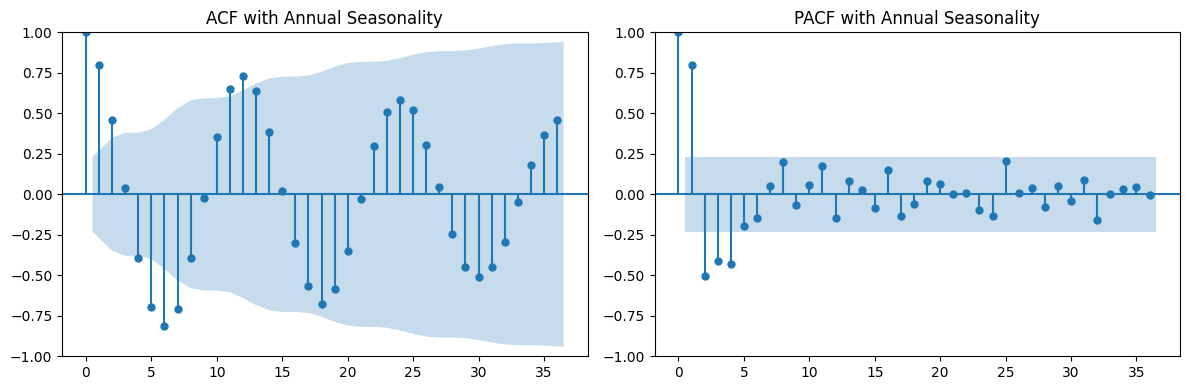

In [3]:
# ACF and PACF plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts, lags=36, ax=axes[0])  # Show lags up to 3 years (36 months)
axes[0].set_title('ACF with Annual Seasonality')
plot_pacf(ts, lags=36, ax=axes[1])
axes[1].set_title('PACF with Annual Seasonality')
plt.tight_layout()
plt.show()

#### Identifying and modeling cycles 

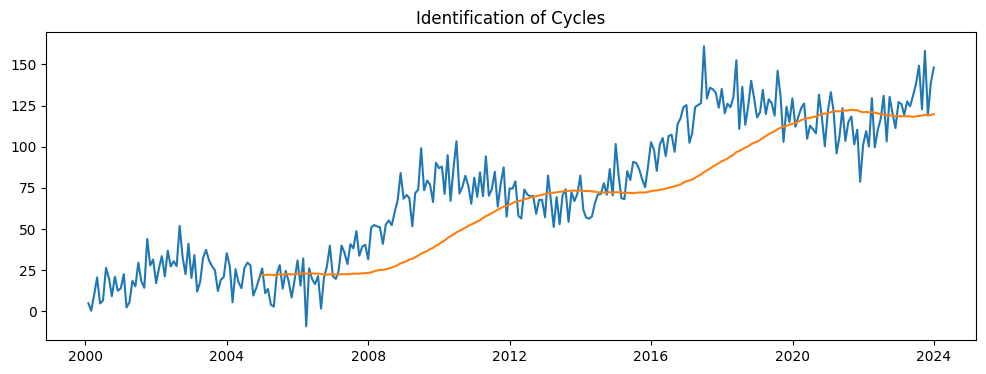

In [4]:
# Create a synthetic time series with a cyclical component
np.random.seed(42)
dates = pd.date_range('2000-01-01', '2023-12-31', freq='M')
n = len(dates)

# Simulate a cycle with a period of roughly 8 years (96 months)
cycle_period = 96
cycle = 20 * np.sin(2 * np.pi * np.arange(n) / cycle_period)

# Add a trend and some random noise
trend = 0.5 * np.arange(n)
noise = np.random.randn(n) * 10

ts = pd.Series(trend + cycle + noise, index=dates)

#Plot
plt.figure(figsize=(12,4))
plt.title('Identification of Cycles')
plt.plot(ts, label = "Original")
plt.plot(ts.rolling(window = 60).mean(), label = "Rolling Mean")
plt.show()

#### Lag plots, visualizing autocorrelation

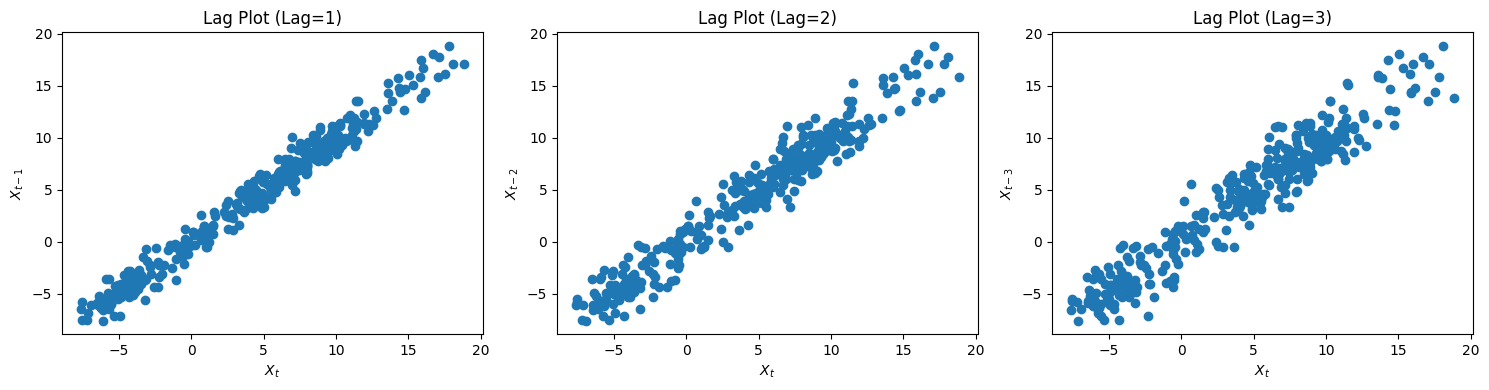

In [5]:
# Create a sample time series for demonstration
dates = pd.date_range('2024-01-01', periods=365, freq='D')
data = np.random.randn(365).cumsum() # Create a random walk for autocorrelation
ts = pd.Series(data, index=dates)


# Create multiple lag plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    lag_plot(ts, lag=i+1, ax=ax)
    ax.set_title(f'Lag Plot (Lag={i+1})')
    ax.set_xlabel('$X_t$')
    ax.set_ylabel(f'$X_{{t-{i+1}}}$')

plt.tight_layout()
plt.show()

#### Heatmaps, exploring multiple time series and correlations

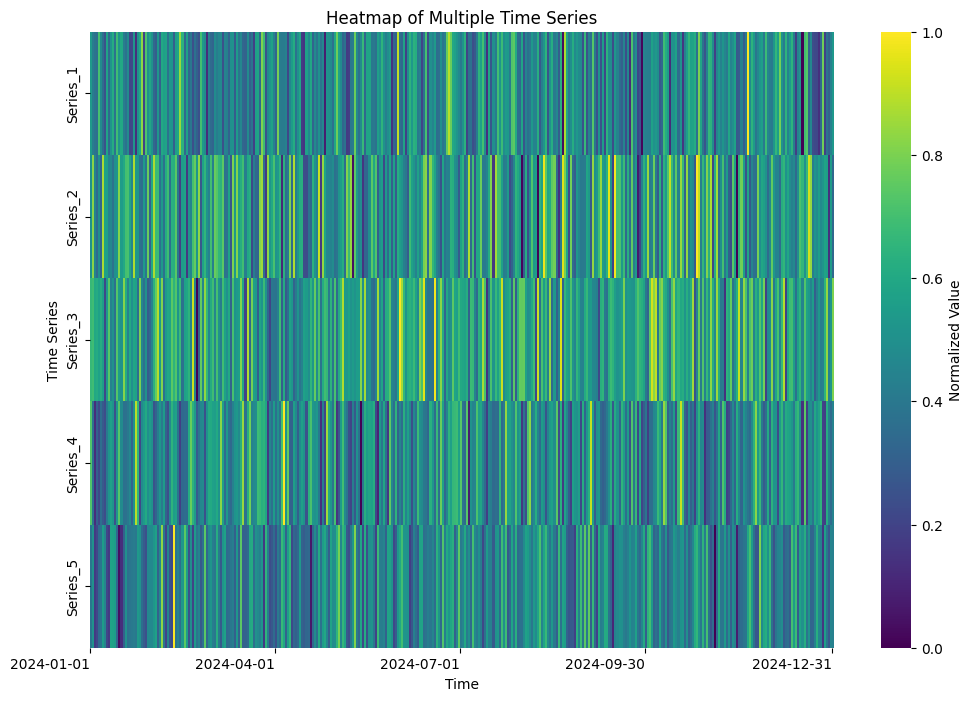

In [6]:
# Create synthetic data for multiple time series
np.random.seed(42)
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')
n_series = 5
data = np.random.randn(len(dates), n_series)  # 5 time series
df = pd.DataFrame(data, index=dates, columns=[f'Series_{i+1}' for i in range(n_series)])

# Normalize the data (important for visualization)
df_normalized = (df - df.min()) / (df.max() - df.min())

# Create the heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(df_normalized.T, cmap="viridis", cbar_kws={'label': 'Normalized Value'})  # Transpose for better visualization

# Set x-axis ticks to 10 evenly spaced values
num_ticks = 5
tick_positions = np.linspace(0, len(dates) - 1, num_ticks, dtype=int)
tick_labels = [dates[i].strftime('%Y-%m-%d') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0, ha='right')

plt.title('Heatmap of Multiple Time Series')
plt.xlabel('Time')
plt.ylabel('Time Series')
plt.show()

#### Using heatmaps to visualize correlation matrices

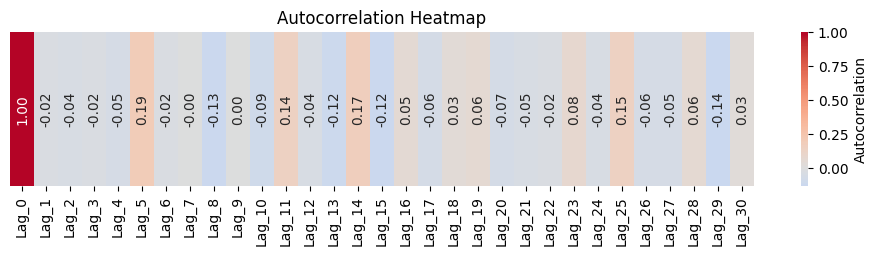

In [7]:
# Sample time series data (Replace 'ts' with actual data)
np.random.seed(42)
ts = np.random.randn(100)

# Calculate the autocorrelation
nlags = 30
acf_values = acf(ts, nlags=nlags)

# Create a DataFrame for the heatmap
acf_df = pd.DataFrame(acf_values.reshape(1, -1), columns=[f'Lag_{i}' for i in range(nlags + 1)])

# Create the heatmap
plt.figure(figsize=(12, 2))  # Wider figure for better visualization
ax = sns.heatmap(acf_df, annot=True, cmap="coolwarm", center=0,
                 cbar_kws={'label': 'Autocorrelation'}, fmt=".2f")

# Rotate the text inside the heatmap (annotations) to 90 degrees
for text in ax.texts:
    text.set_rotation(90)  # Rotate text labels inside the heatmap

plt.title('Autocorrelation Heatmap')
plt.yticks([])  # Remove y-axis ticks (only one row)
plt.show()


#### Using heatmaps to visualizing missing values

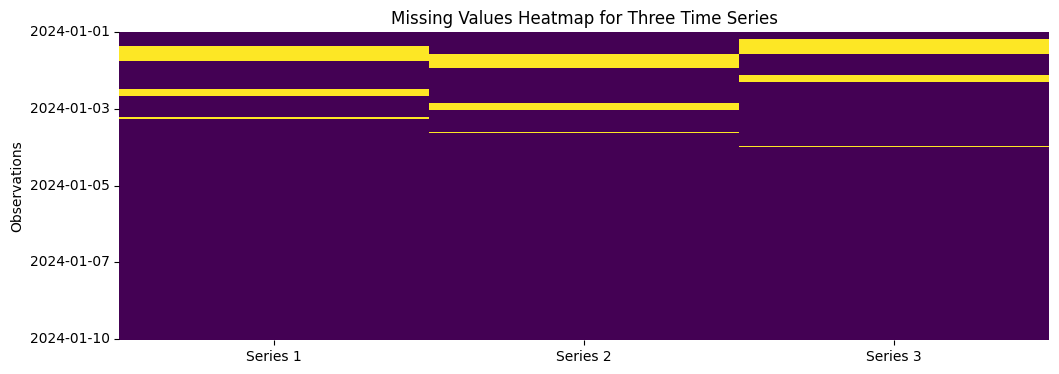

In [8]:
# Example time series data with missing values
date_rng = pd.date_range(start='2024-01-01', end='2024-01-10', freq='H')

# Generate random data for three time series
np.random.seed(42)
data1 = np.random.randn(len(date_rng))
data2 = np.random.randn(len(date_rng))
data3 = np.random.randn(len(date_rng))

# Introduce missing values at different positions
data1[10:20] = np.nan  
data1[40:45] = np.nan
data1[60] = np.nan

data2[15:25] = np.nan  
data2[50:55] = np.nan
data2[70] = np.nan

data3[5:15] = np.nan  
data3[30:35] = np.nan
data3[80] = np.nan

# Create a DataFrame with multiple series
df = pd.DataFrame({
    'Series 1': data1,
    'Series 2': data2,
    'Series 3': data3
}, index=date_rng)

# Create a heatmap of missing values
plt.figure(figsize=(12, 4))
ax = sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

# Set x-axis ticks to 5 evenly spaced values
num_ticks = 5
tick_positions = np.linspace(0, len(date_rng) - 1, num_ticks, dtype=int)
tick_labels = [date_rng[i].strftime('%Y-%m-%d') for i in tick_positions]

ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0, ha='right')  # Rotate to 90 degrees for better readability

plt.title('Missing Values Heatmap for Three Time Series')
plt.ylabel('Observations')

plt.show()

#### Seasonal subseries plots

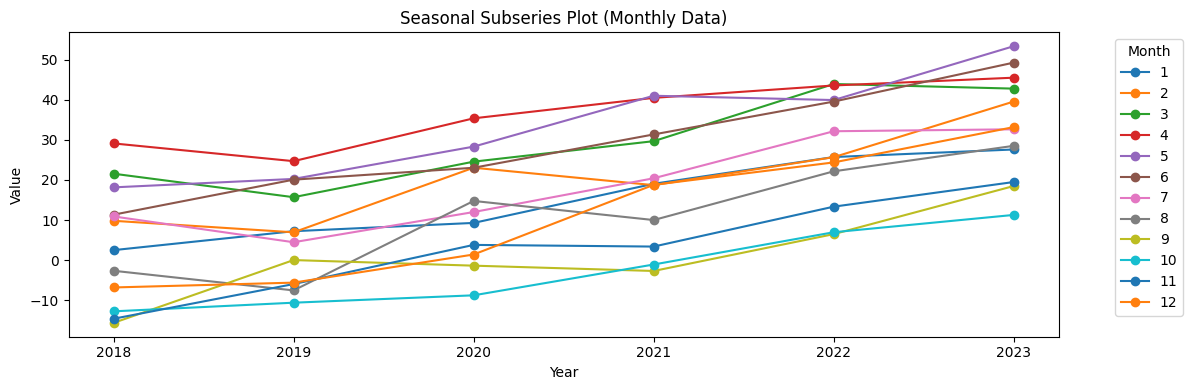

In [9]:
# Create synthetic monthly data with annual seasonality
np.random.seed(42)
dates = pd.date_range('2018-01-01', '2023-12-31', freq='M')
n = len(dates)
seasonal_pattern = 20 * np.sin(2 * np.pi * np.arange(n) / 12)
trend = 0.5 * np.arange(n)
noise = np.random.randn(n) * 5
data = seasonal_pattern + trend + noise
ts = pd.Series(data, index=dates)

# Create the seasonal subseries plot
plt.figure(figsize=(12, 4))  # Adjust figure size for readability
for m in range(1, 13):
    # Extract data for each month
    monthly_data = ts[ts.index.month == m]
    # Plot each month as a separate series, using the year as the x-axis
    #  The year is extracted, and then unique years are used for plotting
    # to handle cases where a month might have missing data in some years.

    plt.plot(monthly_data.index.year, monthly_data.values, label=f'{m}', marker='o')

plt.title('Seasonal Subseries Plot (Monthly Data)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping

plt.show()